## Loading Data
First, we load the data as an AnnData object (`adata`) and run PCA on it

In [2]:
import scanpy as sc

adata = sc.read_h5ad("pancreas_data.h5ad")
sc.pp.pca(adata, n_comps=100)

We can see that the batch labels are in `adata.obs["batch"]` and the 100-dimension PCA embeddings are in `adata.obsm["X_pca"]`:

In [3]:
print("Batches:")
print(adata.obs["batch"].value_counts())
print("\nOBSM keys:", adata.obsm_keys())
print("PCA shape:", adata.obsm["X_pca"].shape)

Batches:
batch
pancreas_inDrop                                4517
pancreas_multi_smartseq2_expression_matrix     1568
pancreas_multi_celseq2_expression_matrix       1453
pancreas_multi_celseq_expression_matrix         494
pancreas_multi_fluidigmc1_expression_matrix     437
Name: count, dtype: int64

OBSM keys: ['X_pca']
PCA shape: (8469, 100)


## Running BatchRefiner
Next, we use BatchRefiner to generate scaled embeddings:

In [4]:
from batchrefiner import batchrefine_scanpy

batchrefine_scanpy(adata, "X_pca", batch_key="batch", br_key = "X_pca_scale_r2", mode="scale", metric="r2", n_proc=8)

We can see the modified embedding, which has the same dimensionality, has been added to `adata`:

In [5]:
print("\nOBSM keys:", adata.obsm_keys())
print("PCA+BatchRefiner shape:", adata.obsm["X_pca_scale_r2"].shape)


OBSM keys: ['X_pca', 'X_pca_scale_r2']
PCA+BatchRefiner shape: (8469, 100)


## Downstream Tasks
We can now run arbitrary downstream tasks using the modified embedding. 
### Benchmarking
For example, we could run benchmarking metrics from scib. Here is an exmaple using the Silhouette Batch (or ASW Batch) batch integration metric:

In [6]:
from scib.metrics import silhouette_batch

score = silhouette_batch(
    adata,
    batch_key="batch",
    label_key="cell_types",
    embed="X_pca_scale_r2",
)

print("Silhouette Batch (ASW_Batch) Score:", score)

mean silhouette per group:        silhouette_score
group                  
alpha          0.859673
beta           0.879341
Silhouette Batch (ASW_Batch) Score: 0.8695068314282227


Alternativly, we could compute several batch correction and bio-integration benchmarks, with and without BatchRefiner, using scib-metrics

In [ ]:
%pip install scib-metrics==0.5.3


In [8]:

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

sc_bm = Benchmarker(
    adata,
    batch_key= "batch",
    label_key= "cell_types",
    embedding_obsm_keys=["X_pca", "X_pca_scale_r2"],
    bio_conservation_metrics = BioConservation(),
    batch_correction_metrics = BatchCorrection(),
    n_jobs=8
)
sc_bm.benchmark()

/home/deschaffer/anaconda3/envs/brtest/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/deschaffer/anaconda3/envs/brtest/lib/python3.10/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/home/deschaffer/anaconda3/envs/brtest/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|                                                                                                                                                    

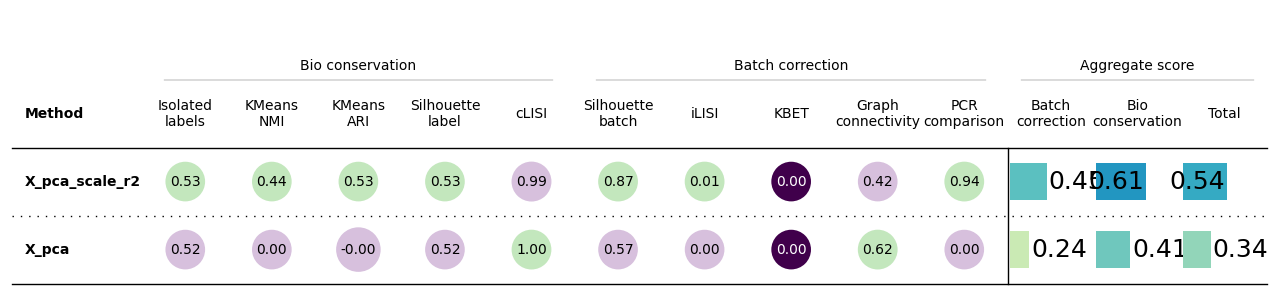

In [9]:
sc_bm.plot_results_table(min_max_scale=False, show=True)

### Visualization
Here is an example of plotting a UMAP using the BatchRefiner embedding:




In [10]:
#Compute neighbors
sc.pp.neighbors(adata, use_rep="X_pca_scale_r2", metric='cosine')
# Compute the UMAP projection, saving it to adata.obsm['X_umap']
sc.tl.umap(adata)



In [11]:
#Plot UMAP
axes = sc.pl.umap(adata, color=("batch", "cell_types"), s=5, legend_loc='right margin', show=False,
                 title=("UMAP of BatchRefiner by Batch", "UMAP of BatchRefiner by Cell Type"))


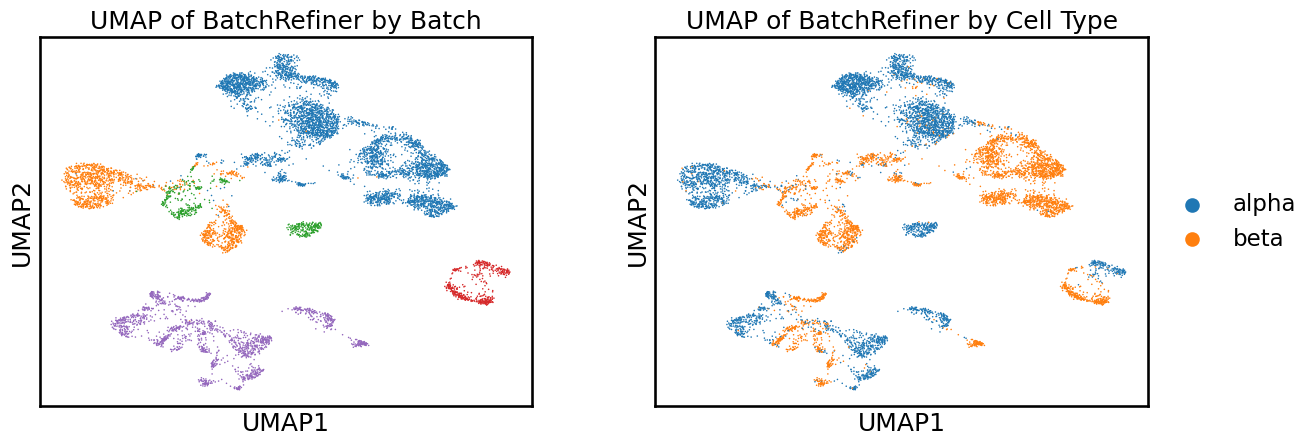

In [12]:
import matplotlib.pyplot as plt

axes[0].get_legend().remove()

plt.show()


Finally, we should save our modified AnnData:

In [13]:
adata.write_h5ad("pancreas_data_br.h5ad", compression="gzip")